## Análisis de Datos

En primer lugar importamos la clase anomalias.py que contiene todos los métodos que vamos a utilizar

In [1]:
from anomalias import Anomalias
from config.columns import COLUMNS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dataframe_image as dfi
import os
from dotenv import load_dotenv

2026-04-26 23:22:36.354213: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-26 23:22:36.854039: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-26 23:22:40.538756: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Instanciamos la clase y obtenemos todos los datos en un único dataframe:

In [2]:
load_dotenv()
anomalias = Anomalias()
df = anomalias.get_data()

# Este codigo simplemente es para generar una imagen del dataset, unicamente con las5 primeras y ultimas columnas para no tener una imagen demasiado grande
'''
first_cols = df.iloc[:, :4]
last_cols = df.iloc[:, -4:]
dots = pd.DataFrame({"...": ["..."] * len(df)})
df_display = pd.concat([first_cols, dots, last_cols], axis=1)
dots_row = pd.DataFrame([["..."] * len(df_display.columns)], columns=df_display.columns)
dots_row.index = ['...']
dfi.export(pd.concat([df_display.head(5), dots_row, df_display.tail(5)]), os.path.join(os.getenv('REPOSITORY_PATH'), 'img/code/df', 'df_head.png'), table_conversion='chrome')
'''

df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830739,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830740,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2830741,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


Un apartado muy importante que se ha de hacer es comprobar las columnas existentes en el dataset:

In [3]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

Vemos que no existen valores nulos en los datos. Esto es por el trabajo del equipo del CIC, ya que proporcionan sus datos perfectamente limpios para su análisis:

In [4]:
# Valores nulos
df_nulls = df.isnull().sum()
df_nulls[df_nulls > 0]

Flow Bytes/s    1358
dtype: int64

Antes de analizar las correlaciones entre variables, vamos a hacer un análisis de outliers. Para ello, obtenemos un dataframe con las columnas que incluyan outliers:

In [5]:
df_outliers = anomalias.get_outliers_df(df)

# Hacemos lo mismo, para guardar el dataframe como imagen
'''
dots_row = pd.DataFrame([["..."] * len(df_outliers.columns)], columns=df_outliers.columns)
dots_row.index = ['...']
dfi.export(pd.concat([df_outliers.head(5), dots_row, df_outliers.tail(5)]), os.path.join(os.getenv('REPOSITORY_PATH'), 'img/code/df', 'outliers.png'), table_conversion='chrome')
'''

df_outliers

,Columna,Número de Outliers,Porcentaje
0,Destination Port,627245,22.158317
1,Flow Duration,532586,18.814354
2,Total Fwd Packets,332693,11.752851
3,Total Backward Packets,308291,10.890816
4,Total Length of Fwd Packets,446972,15.789918
5,Total Length of Bwd Packets,619046,21.868675
6,Fwd Packet Length Max,664214,23.464299
7,Fwd Packet Length Min,14958,0.528413
8,Fwd Packet Length Mean,188020,6.642072
9,Fwd Packet Length Std,663959,23.455291


Vemos que tenemos muchos valores atípicos. Sin embargo no hay que preocuparse, pues esto es normal. El tráfico de una red es muy estocástico, y los datos generalmente son muy asímetricos (los datos no se ajustan siguiendo la campana de Gauss), por lo que se ha subido el valor del coeficiente estándar para capturar outliers de 1.5 a 3. Incluso así obtenemos muchos outliers, en parte por lo que se acaba de explicar, y porque los datos malignos provenientes de un ciberataque por definición ya son outliers por sí solos, aumentando aún más el número final.

A continuación se presenta una prueba irrefutable apoyando lo anterior:

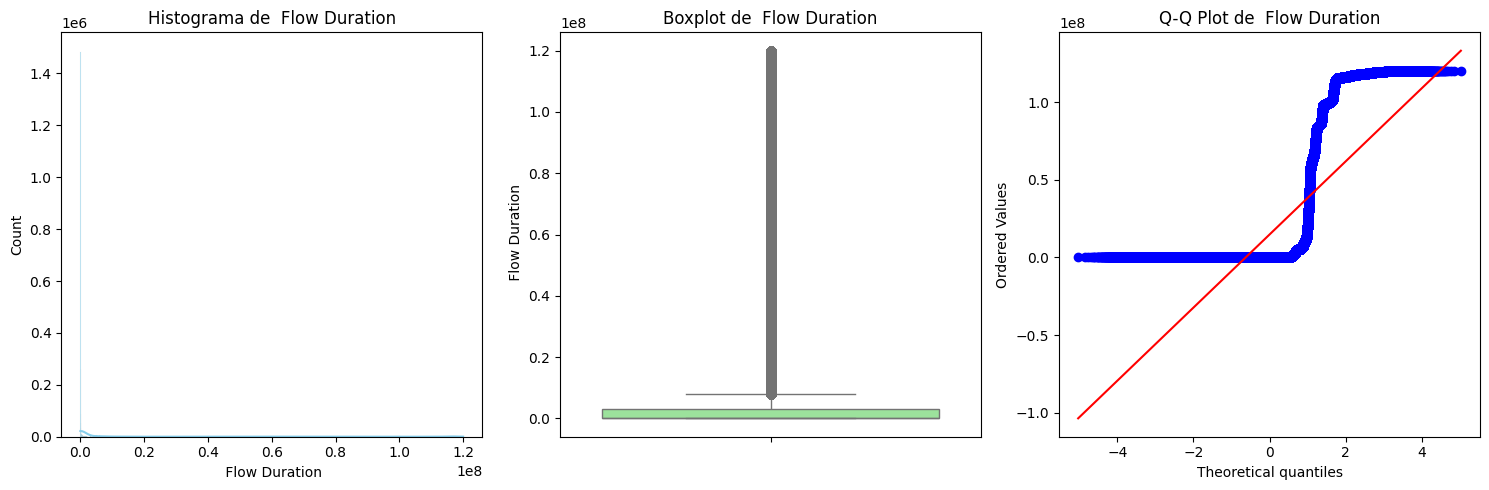

In [6]:
anomalias.plot_normality_test(df, ' Flow Duration')

En esta prueba vemos tres gráficas, un histograma, un diagrama de caja y un Q-Q plot, dichos gráficos realizados sobre la variable `' Flow Duration'` del dataset, ya que esta columna es muy representativa para el modelo, ya que la duración es un aspecto fundamental para explicar el comportamiento de los datos. En el histograma se puede ver que los datos no siguen una campana de Gauss, ya que los datos se encuentran extremadamente sesgados a la derecha, donde la inmensa mayoría de registros tienen un valor muy cercano a cero, y la gran minoría restante forman una cola hasta 1.2e8.

Además, el diagrama de caja refuerza los datos que muestra el histograma, ya que la propia caja del diagrama se encuentra muy cercana a 0 (donde residen la mayoría de datos) y se muestra una gran cantidad de atípicos por encima del límite superior. Por último, el diagrama Q-Q plot termina de reforzar la teoría, ya que se ve claramente que los datos no siguen una distribución normal, sino que se agrupan de una manera que indican una gran cantidad de outliers.

Con esto queda justificado la presencia de multitudes valores atípicos en los datos, ya que los datos del tráfico de red se encuentran demasiado sesgados y dispersos, negándose a seguir una distribución normal. Es por esto que se implementa un modelo `autoencoder`, al presentar una arquitectura no lineal se ajusta mucho mejor a los datos, pudiendo aprender a partir de su comportamiento y características sin depender de supuestos gaussianos.

Una vez hemos visto el análisis de valores atípicos, hemos de comprobar que las distintas columnas no estén muy relacionadas entre sí, ya que el futuro modelo sería redundante y estaríamos procesando información de más que no aporta nada a la red. Para ello, obtenemos la matriz de correlación del dataset:

/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


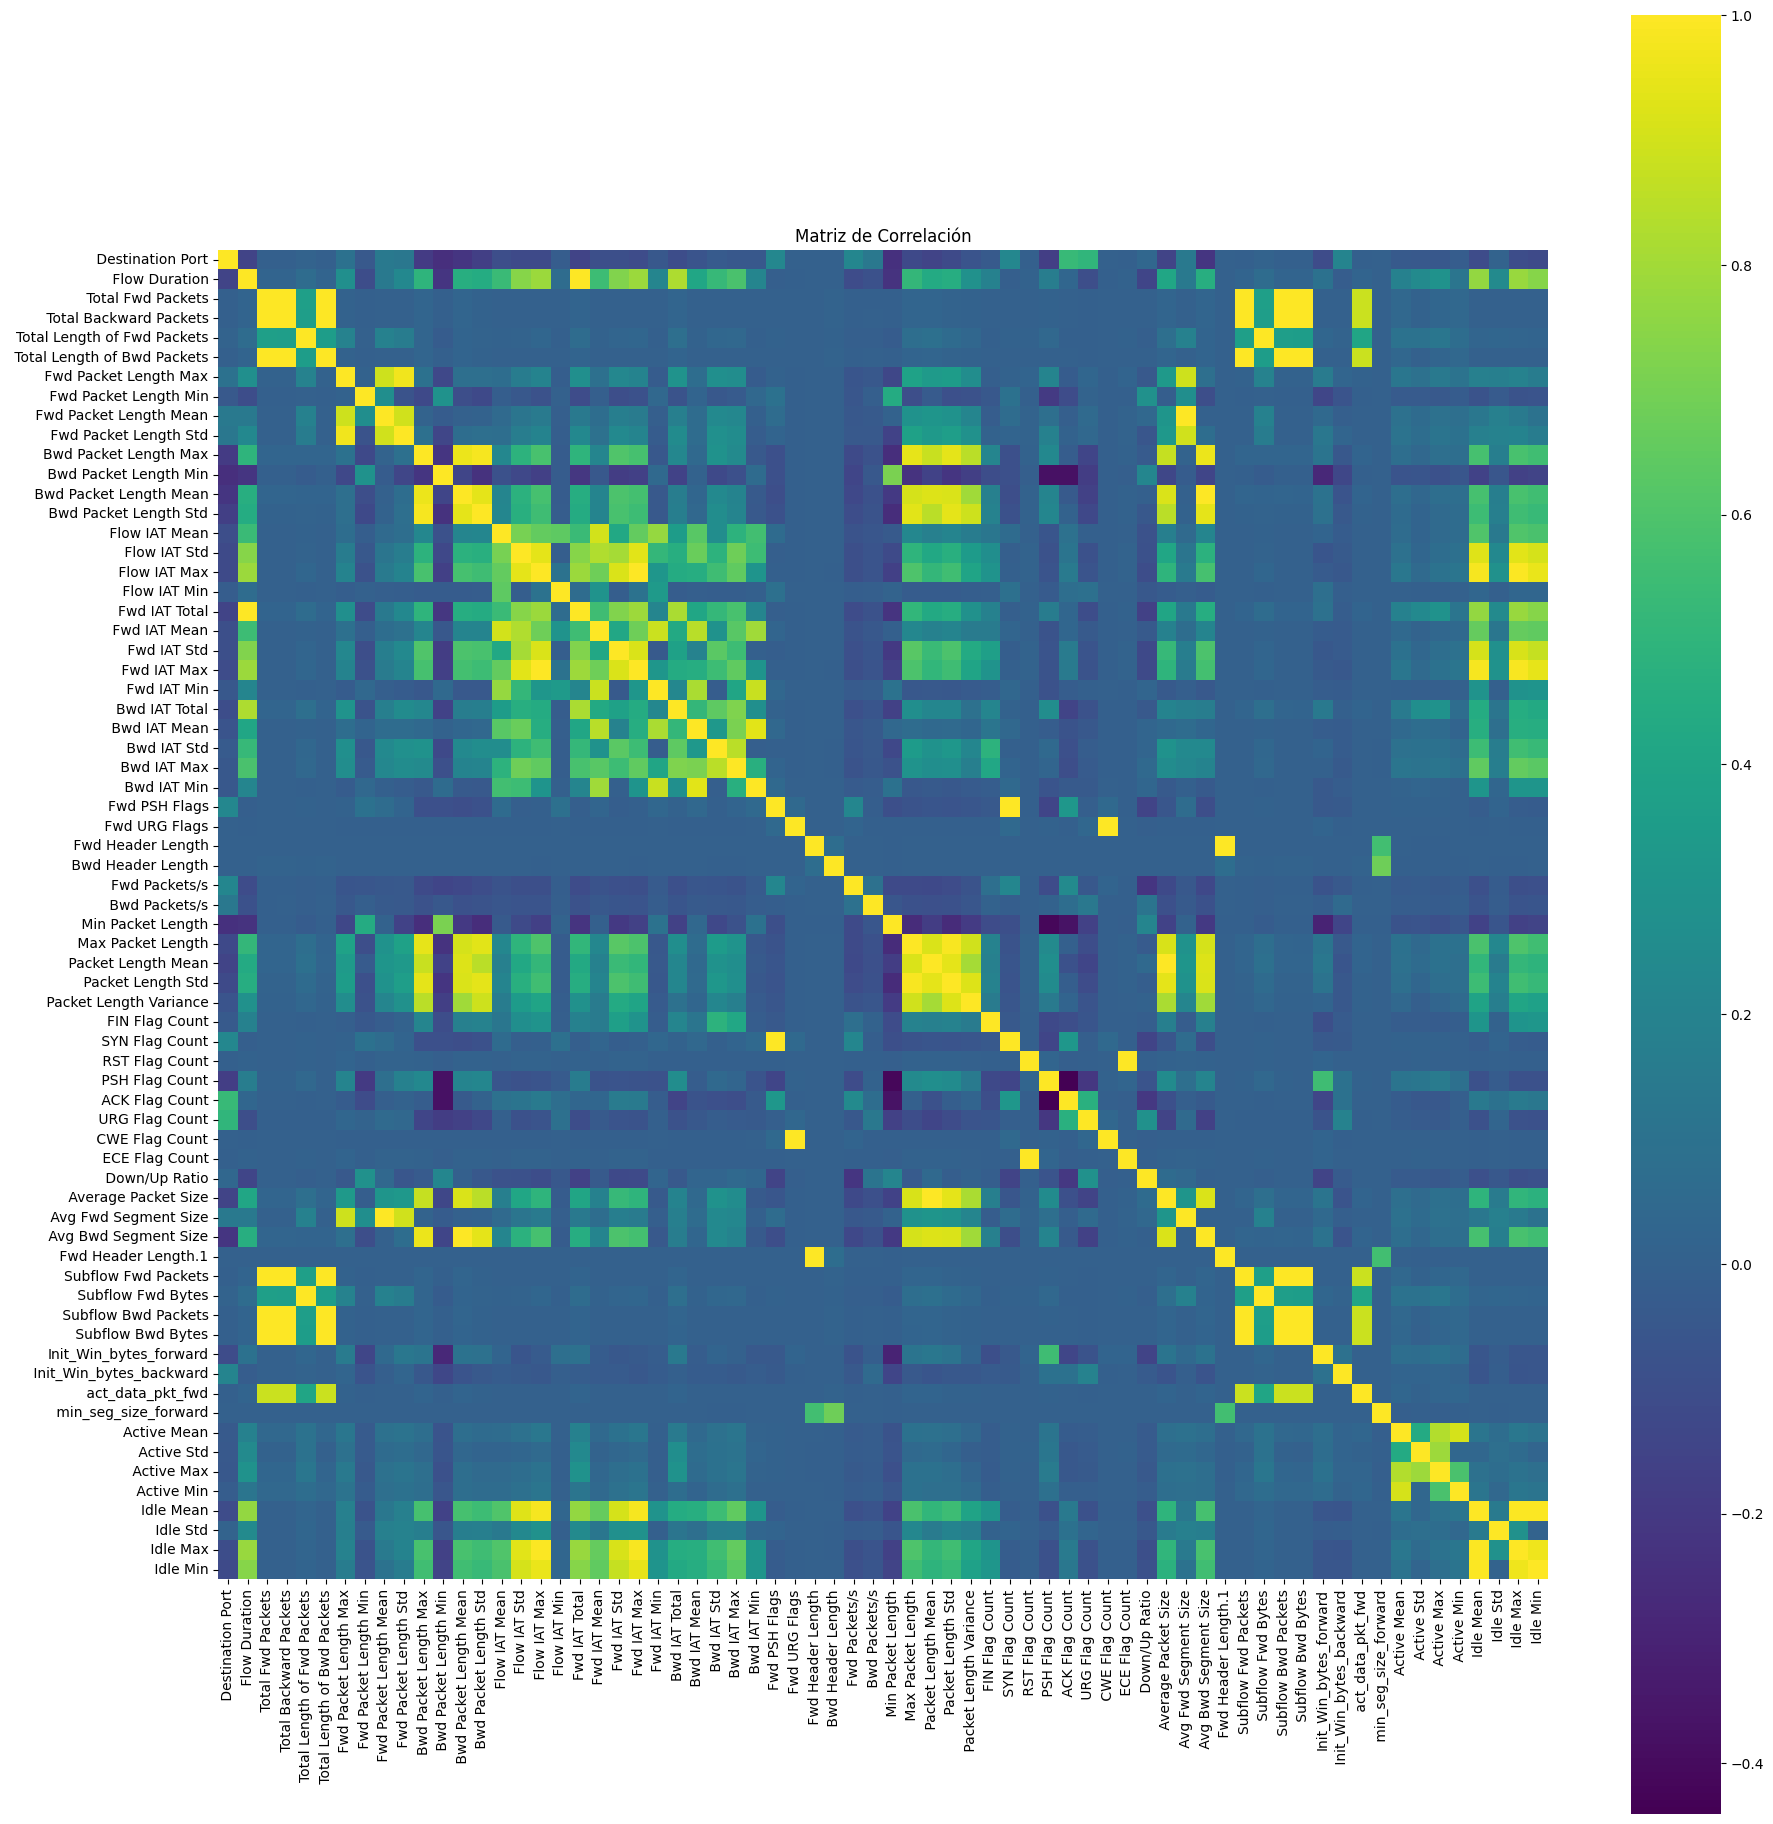

In [3]:
corr_matrix_df = anomalias.get_corr_matrix_from_df(df)
anomalias.plot_correlation_matrix(corr_matrix_df, 'matriz_correlacion.png', 19)

Vemos que hay ciertas columnas bastante correlacionadas entre sí, con un valor de correlación muy cercano a 1. Por lo tanto eliminamos una variable por cada par de columnas altamente correlacionadas (se ha definido el umbral en 0.95).

Además, se van a eliminar otras variables del dataset. Esto es debido a las limitaciones de la librería `NFStream` para capturar paquetes en tiempo real, ya que no se obtiene información de las siguientes columnas (por lo tanto, para que el modelo funcione correctamente con datos en tiempo real, lo mejor es eliminarlas):

In [4]:
drop_columns = ['Init_Win_bytes_forward',
            ' Init_Win_bytes_backward',
            ' min_seg_size_forward',
            'Fwd Avg Bytes/Bulk', 
            ' Fwd Avg Packets/Bulk', 
            ' Fwd Avg Bulk Rate',
            ' Bwd Avg Bytes/Bulk', 
            ' Bwd Avg Packets/Bulk', 
            'Bwd Avg Bulk Rate',
            ' Fwd Header Length',
            ' Bwd Header Length'
]    

df = df.drop(columns=drop_columns)

Una vez hecho esto, volvemos a mostrar la matriz de correlación, esta vez ya con los datos mucho más limpios:

Se eliminaran 22 columnas: [' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Std', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Fwd IAT Total', ' Fwd IAT Max', ' Packet Length Std', ' SYN Flag Count', ' CWE Flag Count', ' ECE Flag Count', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', 'Subflow Fwd Packets', ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Idle Mean', ' Idle Max', ' Idle Min']


/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


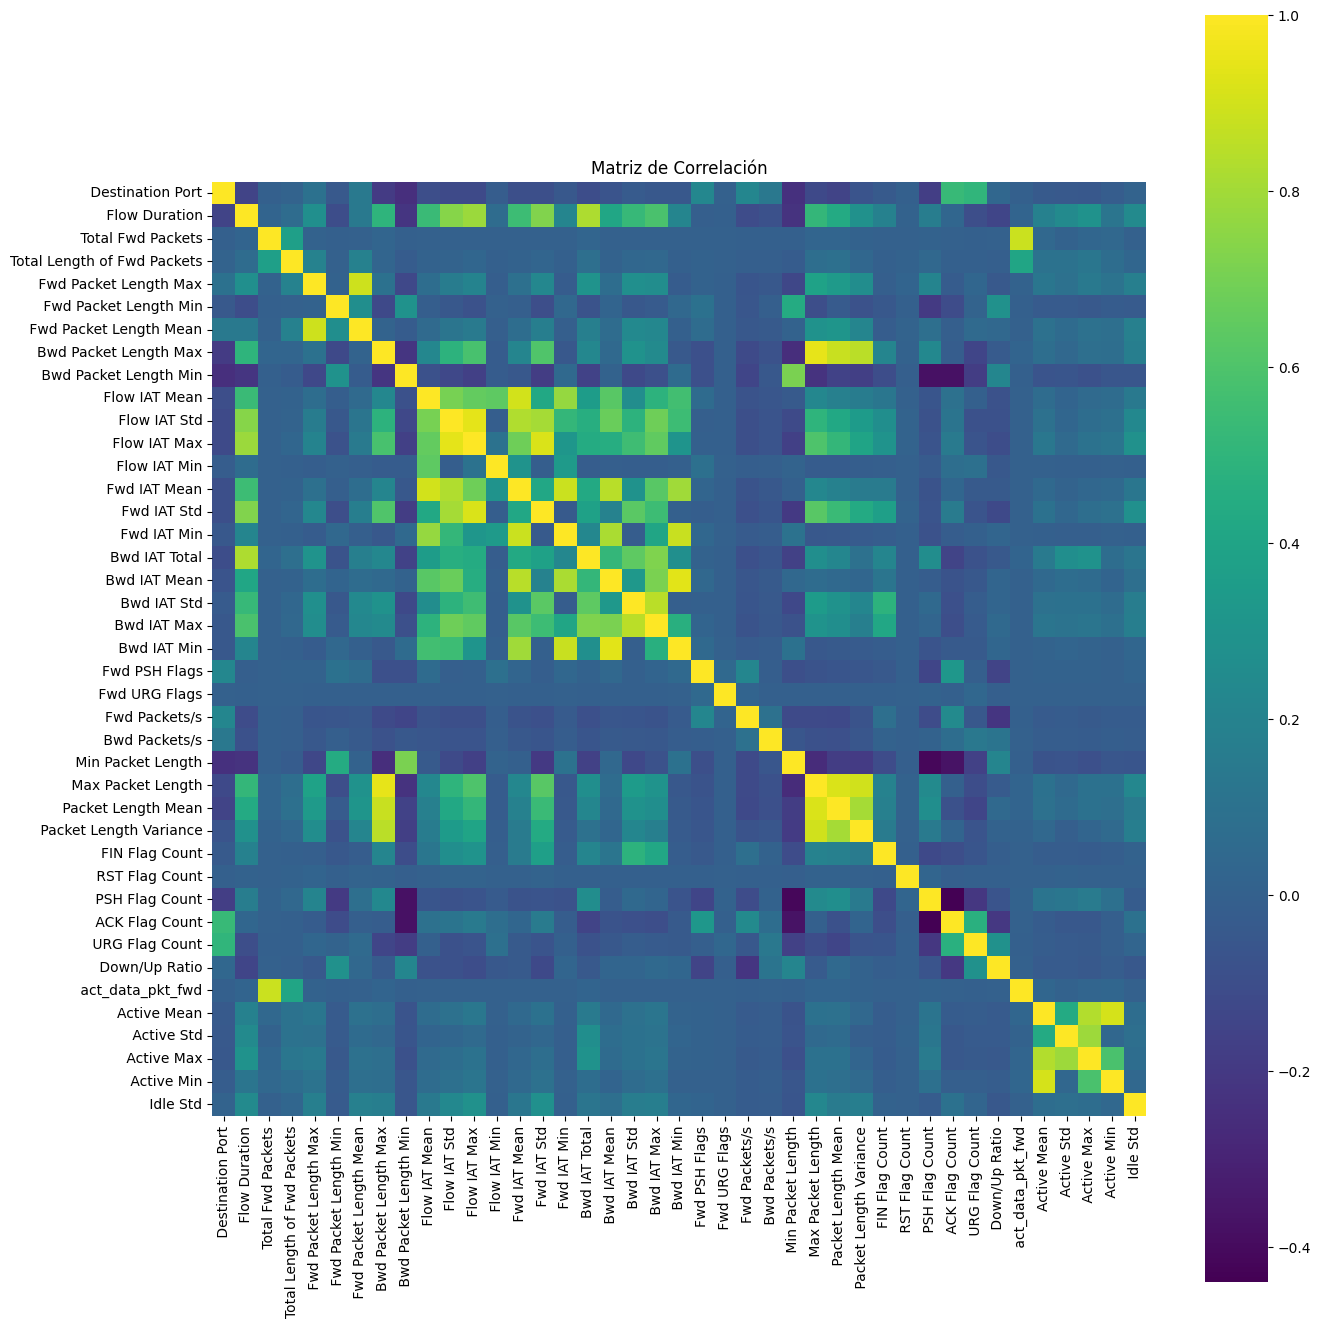

In [5]:
df_corr_cleaned = anomalias.get_df_corr_cleaned(df, corr_matrix_df, 0.95)
corr_matrix_df_cleaned = anomalias.get_corr_matrix_from_df(df_corr_cleaned)
anomalias.plot_correlation_matrix(corr_matrix_df_cleaned, 'matriz_correlacion_cleaned.png', 14)

Podemos ver que de esta manera se ha reducido mucho la redundancia del dataset, lo que propiciará un mejor rendimiento de la red.

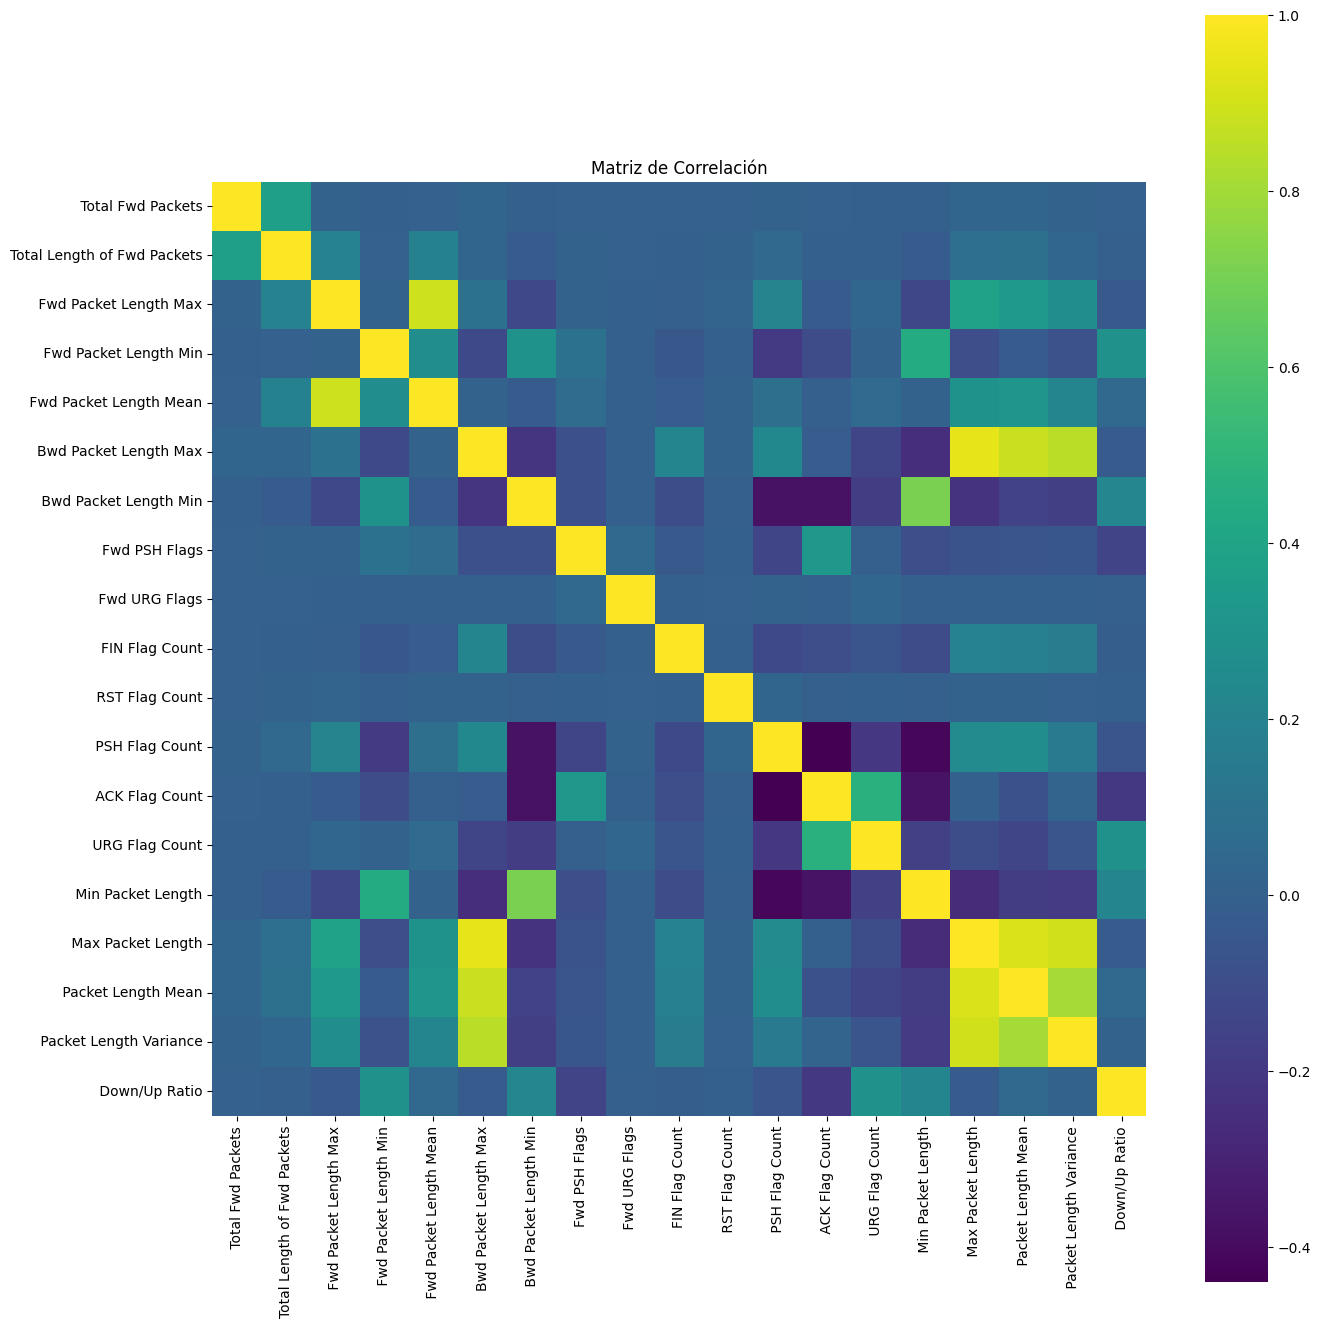

In [10]:
final_columns = COLUMNS + [' Label']
df_corr_cleaned_final = df_corr_cleaned[final_columns]

corr_matrix_df_cleaned_final = anomalias.get_corr_matrix_from_df(df_corr_cleaned_final)
anomalias.plot_correlation_matrix(corr_matrix_df_cleaned_final, 'matriz_correlacion_cleaned_final.png', 14)

Otro apartado bastante importante es separar los datos benignos de los malignos:

In [11]:
df_benign = anomalias.get_df_benign(df_corr_cleaned_final)
df_malign = anomalias.get_df_malign(df_corr_cleaned_final)

porc_benign = round((len(df_benign) / len(df_corr_cleaned_final)) * 100, 2)
porc_malign = round((len(df_malign) / len(df_corr_cleaned_final)) * 100, 2)

df_resumen = pd.DataFrame({
    "Tipo": ["Benignos", "Malignos"],
    "Número de Logs": [len(df_benign), len(df_malign)],
    "Porcentaje": [porc_benign, porc_malign]
})

dfi.export(df_resumen, os.path.join(os.getenv('REPOSITORY_PATH'), 'img/code/df', 'benignos_vs_malignos.png'), table_conversion='chrome')

df_resumen

,Tipo,Número de Logs,Porcentaje
0,Benignos,2273097,80.3
1,Malignos,557646,19.7


In [12]:
df_outliers_benign = anomalias.get_outliers_df(df_benign)
df_outliers_benign

,Columna,Número de Outliers,Porcentaje
0,Total Fwd Packets,393955,17.331201
1,Total Length of Fwd Packets,463682,20.398690
2,Fwd Packet Length Max,516258,22.711657
3,Fwd Packet Length Min,11001,0.483965
4,Fwd Packet Length Mean,167231,7.356967
5,Bwd Packet Length Max,413486,18.190425
6,Bwd Packet Length Min,37058,1.630287
7,Min Packet Length,6440,0.283314
8,Max Packet Length,458539,20.172434
9,Packet Length Mean,286123,12.587364


In [13]:
df_outliers_malign = anomalias.get_outliers_df(df_malign)
df_outliers_malign

,Columna,Número de Outliers,Porcentaje
0,Total Fwd Packets,5297,0.949886
1,Total Length of Fwd Packets,13477,2.416766
2,Fwd Packet Length Max,386,0.069220
3,Fwd Packet Length Mean,20428,3.663256
4,Bwd Packet Length Max,5,0.000897
5,Bwd Packet Length Min,60,0.010760
6,Max Packet Length,28,0.005021
7,Packet Length Variance,33331,5.977089
8,Down/Up Ratio,790,0.141667


/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/code/anomalias.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x=' Label', order=df_plot[' Label'].value_counts().index, palette='bright')


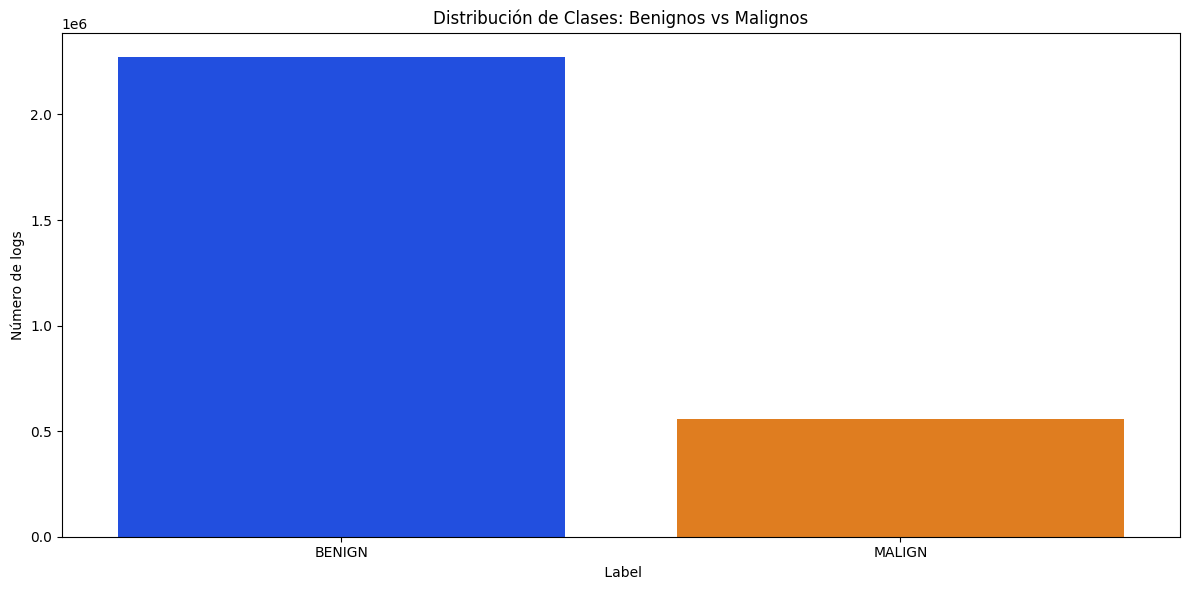

In [14]:
anomalias.plot_class_distribution()

Y como podemos ver, los logs benignos abarcan un 80% de los datos mientras que los malignos un 20%. Esto es importante ya que queremos que la mayoría de datos sean benignos para entrenar el autoencoder, aunque necesitamos una cierta cantidad de logs malignos verificar que la red neuronal (autoencoder) funciona correctamente (esto lo veremos al final de este jupyter)

También es importante conocer los distintos ataques que se han etiquetado a los logs malignos, ya que muchos de estos nos servirán para detectar el tipo de anomalía en nuestro servidor. Principalmente para nuestro servidor web nos fijaremos en DDoS, Brute Force, XSS y SQL Injection (aunque de este último tipo no tenemos muchos datos):

In [15]:
df_malign_counts = df_malign[' Label'].value_counts().reset_index()
df_malign_counts.columns = ['Label', 'Número de Logs']
# Creamos una nueva columna que calcula el porcentaje
df_malign_counts['Porcentaje'] = round((df_malign_counts['Número de Logs'] / df_malign_counts['Número de Logs'].sum()) * 100, 2)

dfi.export(df_malign_counts, os.path.join(os.getenv('REPOSITORY_PATH'), 'img/code/df', 'counts_malignos.png'), table_conversion='chrome')

df_malign_counts

,Label,Número de Logs,Porcentaje
0,DoS Hulk,231073,41.44
1,PortScan,158930,28.50
2,DDoS,128027,22.96
3,DoS GoldenEye,10293,1.85
4,FTP-Patator,7938,1.42
5,SSH-Patator,5897,1.06
6,DoS slowloris,5796,1.04
7,DoS Slowhttptest,5499,0.99
8,Bot,1966,0.35
9,Web Attack � Brute Force,1507,0.27


/home/moyis/Desktop/UAX/Quinto/TFG/AnomaliasTFG/code/anomalias.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x=' Label', order=df_plot[' Label'].value_counts().index, palette='bright')


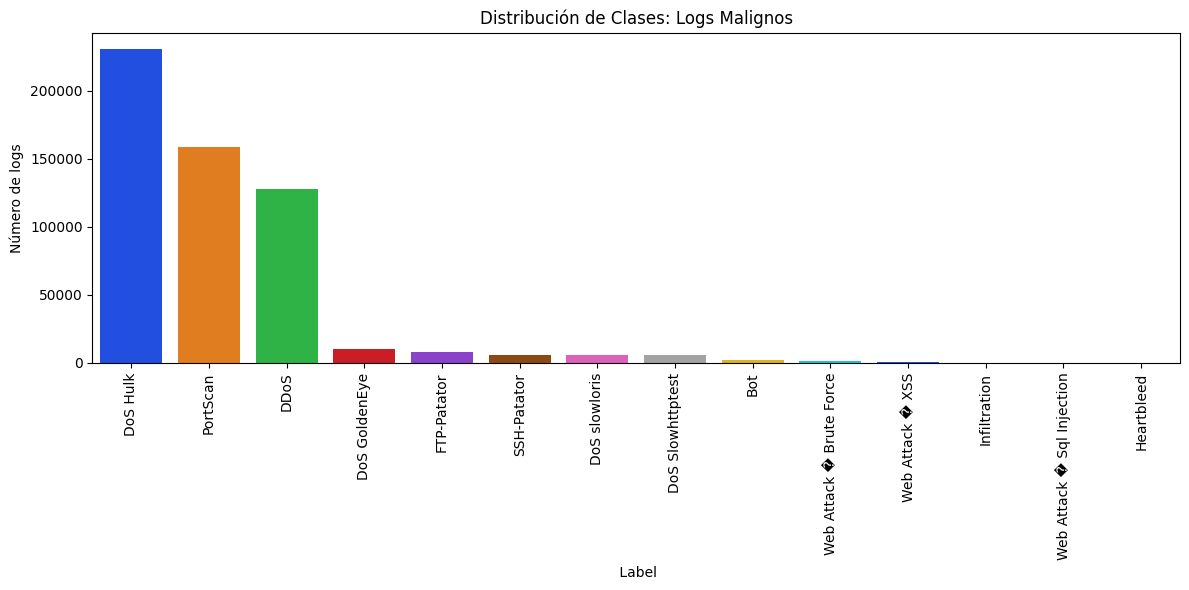

In [16]:
anomalias.plot_class_distribution(malign=True)

Con esto vemos de manera gráfica que los ataques más frecuentes son `DoS Hulk`, `PortScan`, `DDoS`, los cuales muy probablemente, al tener mayor volumen de datos, sean los que el futuro modelo de clasificación predizca mejor. No obstante esto lo haremos más adelante.

## Autoencoder

Una vez hecho esto ya podemos pasar al autoencoder. Para ello tenemos que hacer una pequeña limpieza, ya que encontramos valores de infinito en el dataset los cuales debemos eliminar antes de entrenar el modelo. A su vez tenemos que normalizar dichos datos (escalar sus valores entre 0 y 1) para que el modelo funcione de la mejor manera posible. Esto lo hacemos de la siguiente manera: 

In [17]:
df_benign_cleaned = anomalias.clean_df(df_to_clean=df_benign)
anomalias.save_df_csv(df_benign_cleaned, 'df_benign_cleaned')
df_malign_cleaned = anomalias.clean_df(df_to_clean=df_malign)
anomalias.save_df_csv(df_malign_cleaned, 'df_malign_cleaned')

# Eliminamos la etiqueta label
df_benign_cleaned = df_benign_cleaned.drop(columns=[' Label'])
df_malign_cleaned = df_malign_cleaned.drop(columns=[' Label'])



X_train_scaled, X_test_scaled = anomalias.get_scaled_train_test_data(df_benign_cleaned)
print('Tamaño de datos de entrenamiento: ', X_train_scaled.shape)
print('Tamaño de datos de test: ', X_test_scaled.shape)

Tamaño de datos de entrenamiento:  (1818477, 21)
Tamaño de datos de test:  (454620, 21)


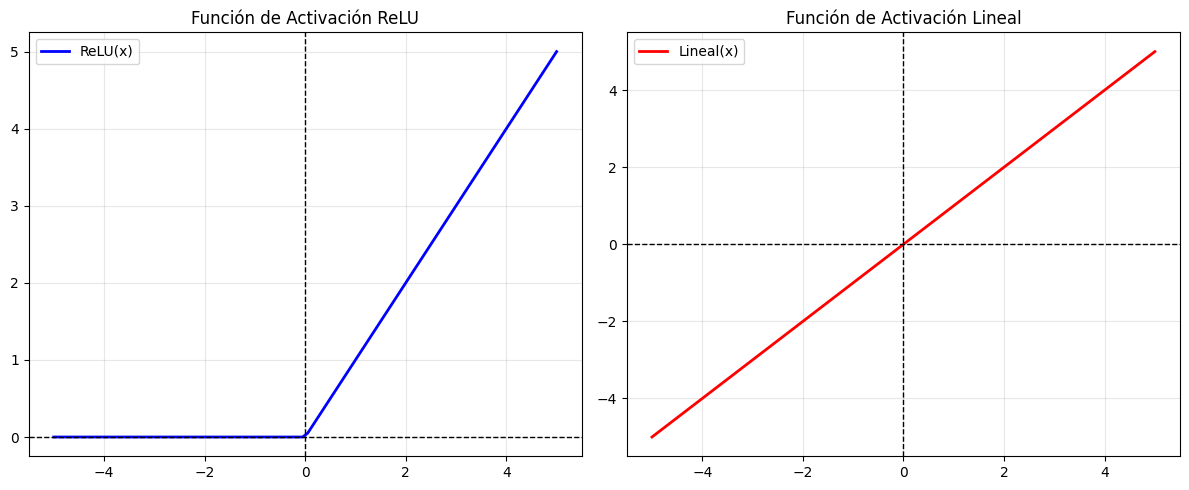

In [3]:
def relu(x):
    return np.maximum(0, x)

def linear(x):
    return x

# Generar datos
x = np.linspace(-5, 5, 100)
y_relu = relu(x)
y_linear = linear(x)

# Configuración visual
plt.figure(figsize=(12, 5))

# Gráfico ReLU
plt.subplot(1, 2, 1)
plt.plot(x, y_relu, label='ReLU(x)', color='blue', lw=2)
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.title('Función de Activación ReLU')
plt.grid(alpha=0.3)
plt.legend()

# Gráfico funcion lineal
plt.subplot(1, 2, 2)
plt.plot(x, y_linear, label='Lineal(x)', color='red', lw=2)
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.title('Función de Activación Lineal')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('../img/code/relu_linear.png')
plt.show()

A continuación ya nos encontramos en condiciones de entrenar un primer modelo, un modelo muy básico pero que nos va a servir para comprobar que la teoría es cierta:

In [19]:
autoencoder, history = anomalias.create_and_train_autoencoder(X_train_scaled, X_test_scaled)
scaler = anomalias.get_scaler()

2026-04-19 10:56:15.006573: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Comenzamos el entrenamiento de la red...
Epoch 1/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.2287 - val_loss: 0.3615
Epoch 2/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.1052 - val_loss: 0.3146
Epoch 3/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0950 - val_loss: 0.3404
Epoch 4/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0948 - val_loss: 0.3331
Epoch 5/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0946 - val_loss: 0.3430
Epoch 6/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0944 - val_loss: 0.3220
Epoch 7/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0948 - val_loss: 0.3235
Epoch 8/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0945 - val_loss: 0.3397
Epoch 9/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.0944 - val_loss: 0.3319
Epoch 10/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0946 - val_loss: 0.3323
Epoch 11/30
7104/7104 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0944

Al pasar los datos de los logs malignos por la red neuronal, deberiamos obtener un error cuadratico medio (mse) mucho mayor, vamos a ver si esto es cierto

Para ello tenemos que hacer un preprocesamiento de igual manera que para X_benign
Eliminamos la columna ' Label', eliminamos valores infinitos y normalizamos los datos

In [25]:
X_malign_cleaned = anomalias.clean_df(df_malign_cleaned)
X_malign_clean_scaled = scaler.transform(X_malign_cleaned)

Predecimos los resultados con el modelo (autoencoder) definido anteriormente


In [26]:
results_benign = autoencoder.predict(X_test_scaled)
results_malign = autoencoder.predict(X_malign_clean_scaled)

14207/14207 ━━━━━━━━━━━━━━━━━━━━ 10s 692us/step
17427/17427 ━━━━━━━━━━━━━━━━━━━━ 12s 684us/step


Entonces ya únicamente nos queda calcular el error cuadratico medio para cada caso y comparar los resultados

Segun vimos en la teoria, el error cuadratico medio mse tiene que ser mucho mayor para los logs malignos, ya que la red esta entrenada unicamente con datos benignos, por lo que la tasa de error en este caso se dispararia

In [ ]:
mse_benign = np.mean(np.power(X_test_scaled - results_benign, 2))
mse_malign = np.mean(np.power(X_malign_clean_scaled - results_malign, 2))

df_mse = pd.DataFrame({
    "Tipo": ["Benigno", "Maligno"],
    "MSE": [mse_benign, mse_malign]
})

dfi.export(df_mse, os.path.join(os.getenv('REPOSITORY_PATH'), 'img/code/df', 'mse.png'), table_conversion='chrome')

df_mse

4.411033388470543


,Tipo,MSE
0,Benigno,0.329209
1,Maligno,1.452152


Con estos resultados el error de los datos malignos es aproximadamente 5 veces mas grande que los benignos, lo que supone una diferencia significativa y que cumple perfectamente con lo que esperabamos